In [11]:
# Total Sales and Profit
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")

# Sales by Category
print("\nSales by Category:")
print(df.groupby('Category')['Sales'].sum().sort_values(ascending=False).apply(lambda x: f"${x:,.2f}"))

# Profit by Region
print("\nProfit by Region:")
print(df.groupby('Region')['Profit'].sum().sort_values(ascending=False).apply(lambda x: f"${x:,.2f}"))

Total Sales: $2,297,200.86
Total Profit: $286,397.02

Sales by Category:
Category
Technology         $836,154.03
Furniture          $741,999.80
Office Supplies    $719,047.03
Name: Sales, dtype: object

Profit by Region:
Region
West       $108,418.45
East        $91,522.78
South       $46,749.43
Central     $39,706.36
Name: Profit, dtype: object


## 3. Research Questions & How to Answer Them

### Q1. How does the Discount rate affect overall Profit?
*Why it matters:* Stores often give discounts to boost sales, but it can severely eat into profits.
*Methodology:* Group the data by different discount tiers and calculate the average profit margin for each tier using a simple Bar Chart.

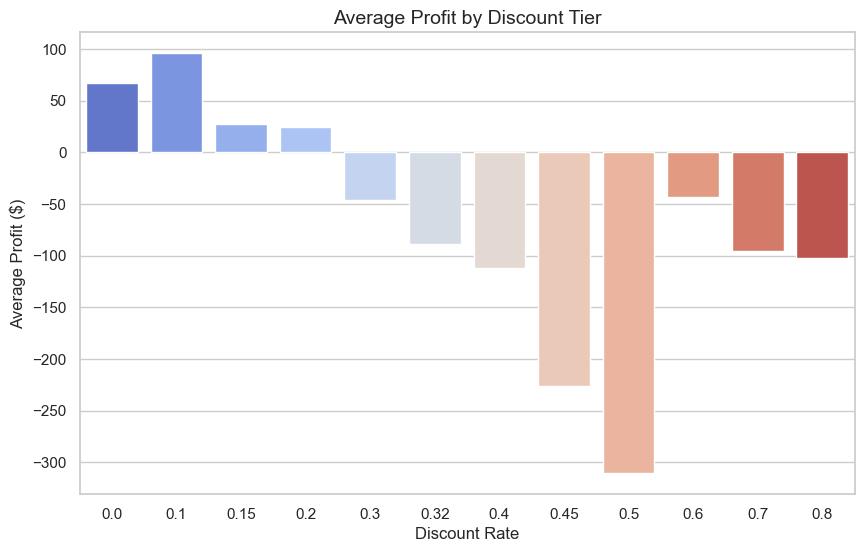

In [12]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Discount', y='Profit', data=df, errorbar=None, palette='coolwarm')
plt.title('Average Profit by Discount Tier', fontsize=14)
plt.xlabel('Discount Rate', fontsize=12)
plt.ylabel('Average Profit ($)', fontsize=12)
plt.show()

### Q2. Which Sub-Category of products is draining the company's profitability?
*Why it matters:* Even if a broad Category (like Furniture) makes money, specific Sub-Categories (like Tables or Bookcases) might be selling at a massive loss.
*Methodology:* Group the data by Sub-Category and sum the Profit. Sort the results in ascending order, visualizing this with a horizontal bar chart highlighting the lowest/negative bars in red.

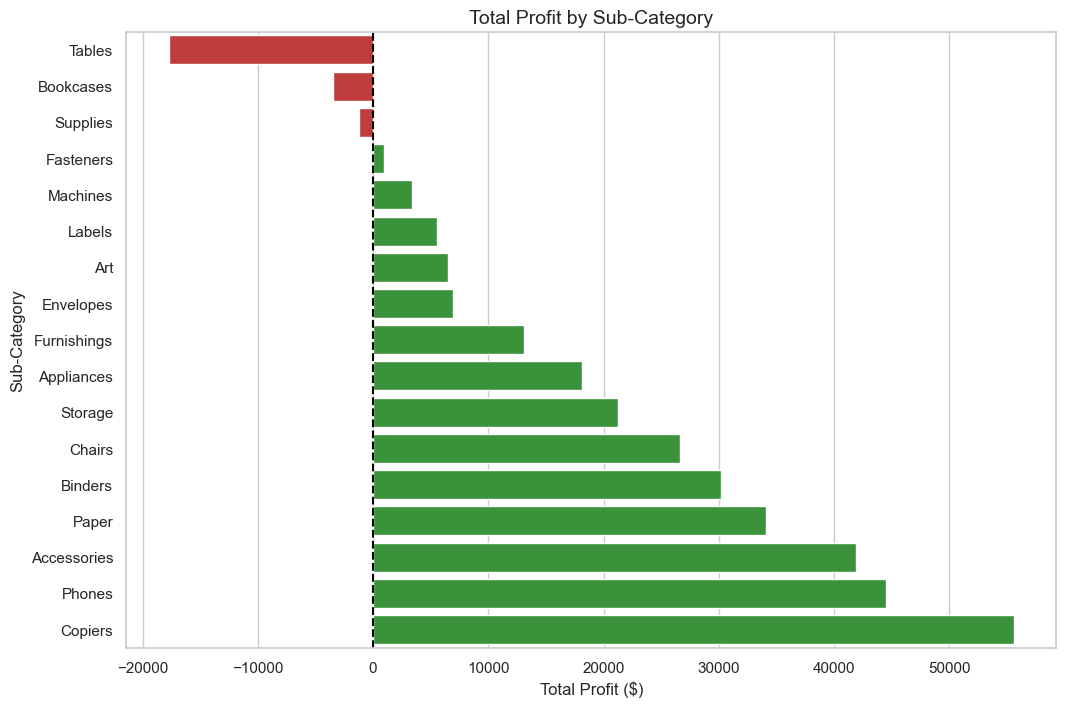

In [13]:
plt.figure(figsize=(12, 8))
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

# Define colors: red for negative profit, green for positive
colors = ['#d62728' if p < 0 else '#2ca02c' for p in subcat_profit]

sns.barplot(x=subcat_profit.values, y=subcat_profit.index, hue=subcat_profit.index, palette=colors, legend=False)
plt.title('Total Profit by Sub-Category', fontsize=14)
plt.xlabel('Total Profit ($)', fontsize=12)
plt.ylabel('Sub-Category', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

### Q3. What is the historical sales trend, and is there seasonal behavior?
*Why it matters:* Understanding when customers buy helps in inventory planning and marketing.
*Methodology:* Extract the Year and Month from the Order Date column. Group the total Sales by Month-Year and plot it on a Line Chart.

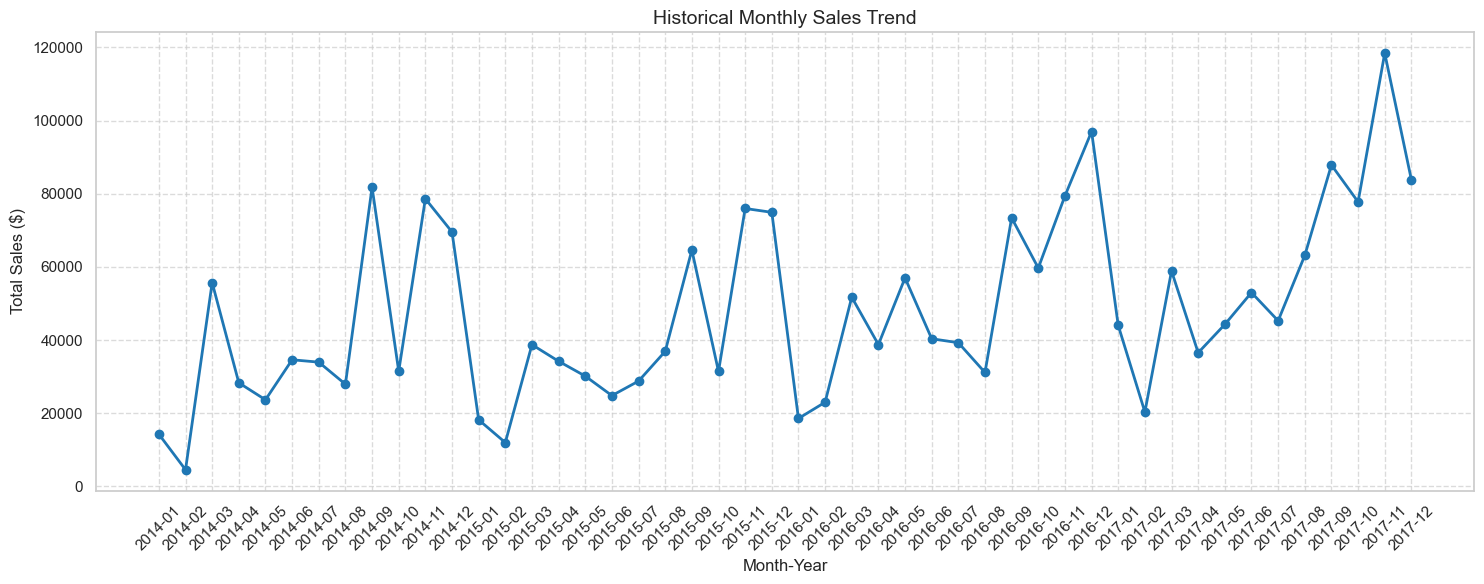

In [14]:
df['Year-Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Year-Month')['Sales'].sum()

plt.figure(figsize=(15, 6))
# Convert Period index to string for plotting
monthly_sales.index = monthly_sales.index.astype(str)
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='#1f77b4', linewidth=2)
plt.title('Historical Monthly Sales Trend', fontsize=14)
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Q4. What is the average delivery time, and does Ship Mode impact customer purchasing behavior?
*Why it matters:* Fast shipping is crucial. Are customers paying for "First Class" actually getting it faster?
*Methodology:* Create a new column called `Shipping Duration` by subtracting `Order Date` from `Ship Date`. Group the data by `Ship Mode` and calculate the average `Shipping Duration`.

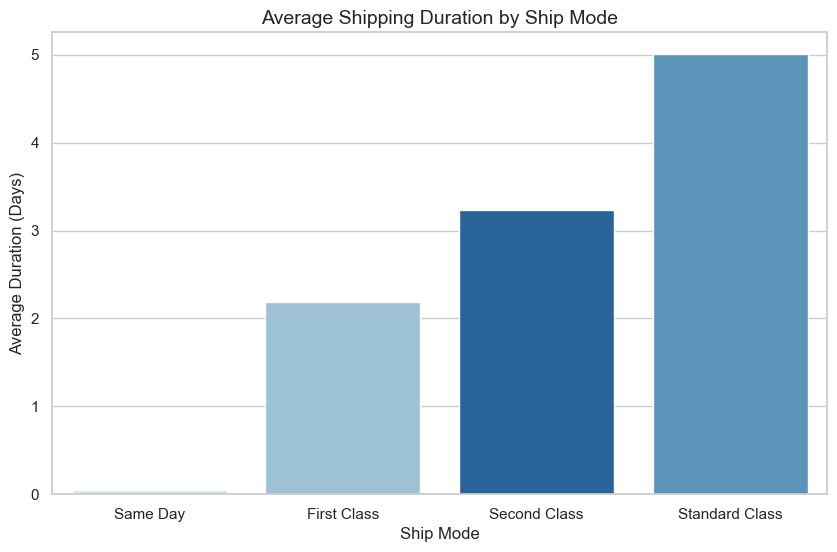

In [15]:
# Calculate Shipping Duration
df['Shipping Duration'] = (df['Ship Date'] - df['Order Date']).dt.days

plt.figure(figsize=(10, 6))
order_modes = ['Same Day', 'First Class', 'Second Class', 'Standard Class']
sns.barplot(x='Ship Mode', y='Shipping Duration', data=df, order=order_modes, errorbar=None, palette='Blues_r', hue='Ship Mode', legend=False)
plt.title('Average Shipping Duration by Ship Mode', fontsize=14)
plt.xlabel('Ship Mode', fontsize=12)
plt.ylabel('Average Duration (Days)', fontsize=12)
plt.show()

### Q5. Which Customer Segment (Consumer, Corporate, Home Office) is the most valuable?
*Why it matters:* To know where to target advertising budgets.
*Methodology:* Calculate Total Sales and Total Profit for each segment. Present Market Share (Sales) as a Pie Chart and Profitability as a Bar Chart.

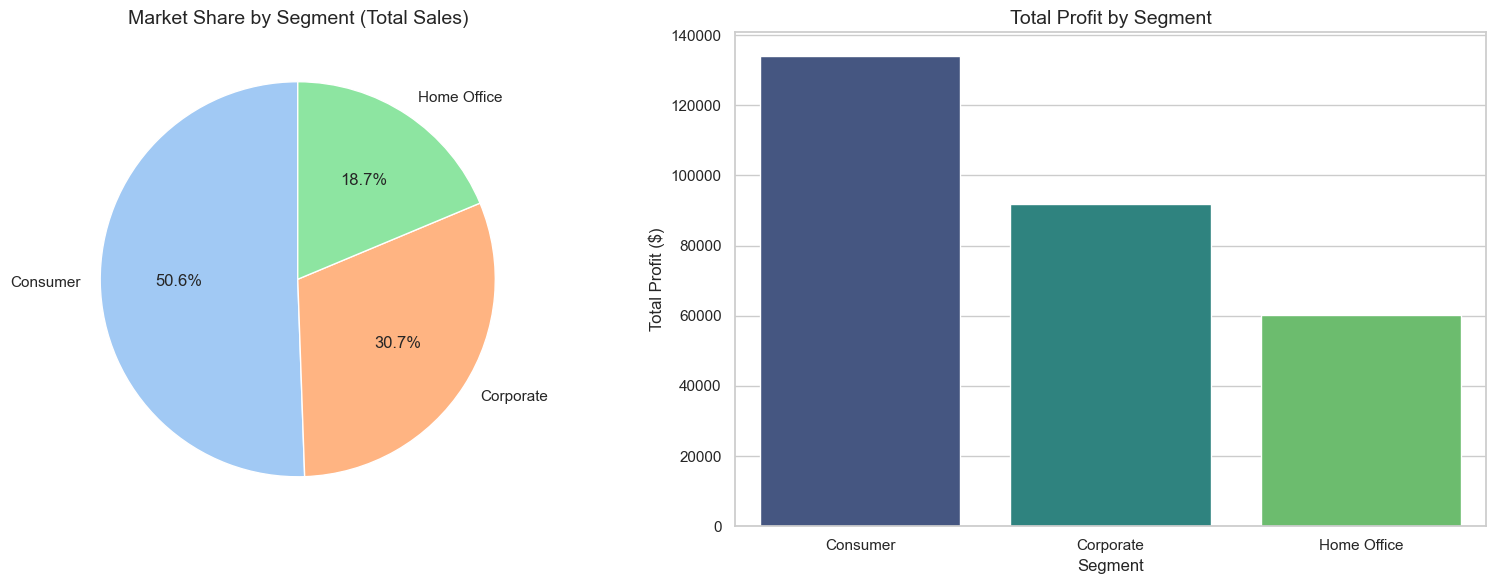

In [16]:
import matplotlib.ticker as ticker

segment_metrics = df.groupby('Segment')[['Sales', 'Profit', 'Quantity']].sum()

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart for Market Share (Total Sales)
ax[0].pie(segment_metrics['Sales'], labels=segment_metrics.index, autopct='%1.1f%%', 
          startangle=90, colors=sns.color_palette('pastel'), wedgeprops={'edgecolor': 'white'})
ax[0].set_title('Market Share by Segment (Total Sales)', fontsize=14)

# Bar chart for Total Profit
sns.barplot(x=segment_metrics.index, y=segment_metrics['Profit'], ax=ax[1], palette='viridis', hue=segment_metrics.index, legend=False)
ax[1].set_title('Total Profit by Segment', fontsize=14)
ax[1].set_ylabel('Total Profit ($)', fontsize=12)
ax[1].set_xlabel('Segment', fontsize=12)

plt.tight_layout()
plt.show()


### Q6. Which specific Products are the most profitable, and which are the least profitable?
*Why it matters:* Identifying top-performing and worst-performing individual products can guide inventory and marketing decisions.
*Methodology:* Group the data by `Product Name` and sum the Profit. Sort the results to find the top 5 and bottom 5 products, and display them using bar charts.

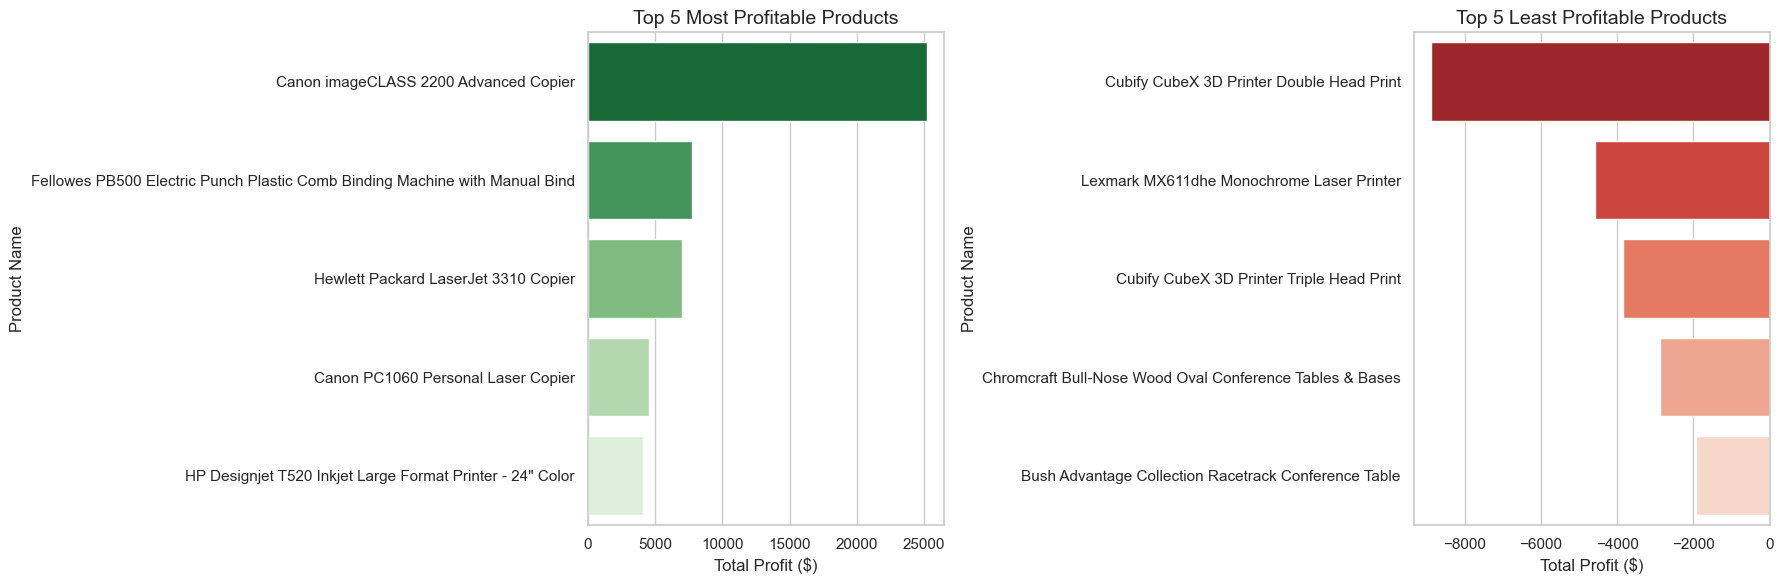

In [17]:
product_profit = df.groupby('Product Name')['Profit'].sum()
top_5_products = product_profit.nlargest(5)
bottom_5_products = product_profit.nsmallest(5)

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Top 5
sns.barplot(x=top_5_products.values, y=top_5_products.index, ax=ax[0], palette='Greens_r')
ax[0].set_title('Top 5 Most Profitable Products', fontsize=14)
ax[0].set_xlabel('Total Profit ($)', fontsize=12)

# Bottom 5
sns.barplot(x=bottom_5_products.values, y=bottom_5_products.index, ax=ax[1], palette='Reds_r')
ax[1].set_title('Top 5 Least Profitable Products', fontsize=14)
ax[1].set_xlabel('Total Profit ($)', fontsize=12)

plt.tight_layout()
plt.show()

### Q7. Are there specific States or Cities where the Superstore is operating at a significant loss?
*Why it matters:* Geographic profitability analysis can reveal areas where shipping costs or regional discounts are destroying margins.
*Methodology:* Group the data by `State`, calculate total Profit, and plot a bar chart highlighting the worst-performing states.

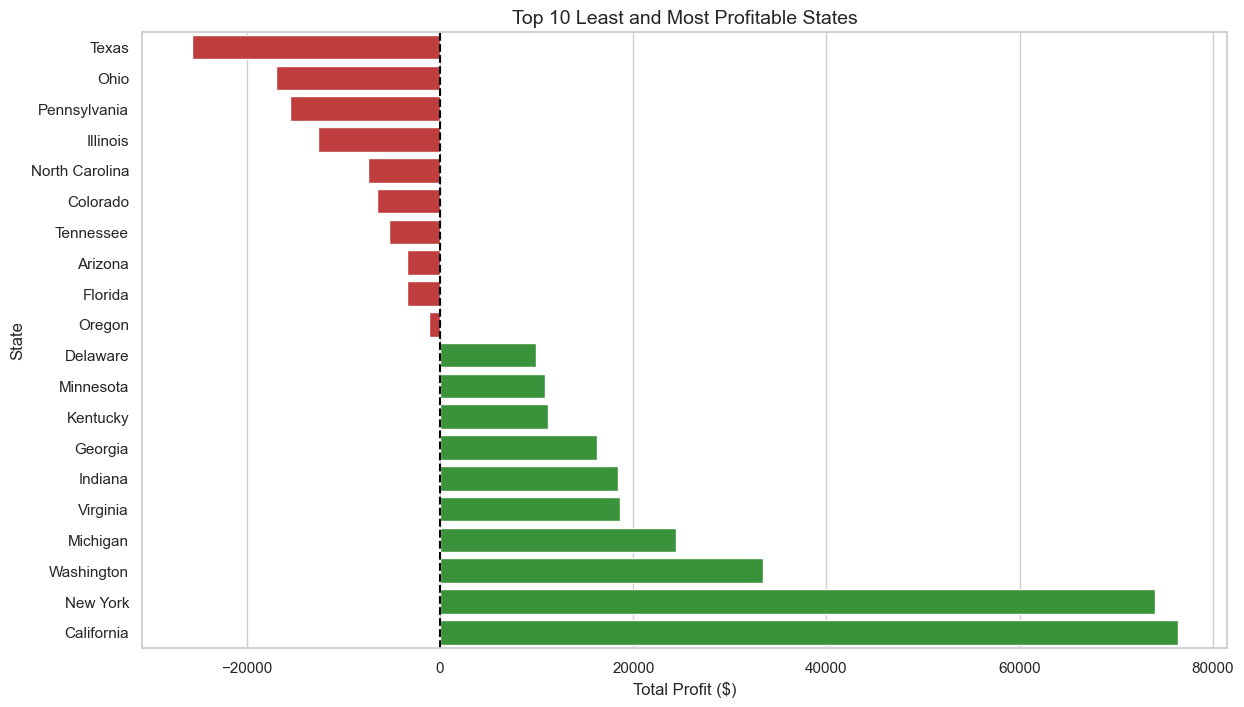

In [18]:
state_profit = df.groupby('State')['Profit'].sum().sort_values()

plt.figure(figsize=(14, 8))
# Only look at bottom 10 and top 10 states for readability
extreme_states = pd.concat([state_profit.head(10), state_profit.tail(10)])
colors = ['#d62728' if p < 0 else '#2ca02c' for p in extreme_states]

sns.barplot(x=extreme_states.values, y=extreme_states.index, palette=colors)
plt.title('Top 10 Least and Most Profitable States', fontsize=14)
plt.xlabel('Total Profit ($)', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

### Q8. What is the average Profit Margin for each Sub-Category?
*Why it matters:* Profit Margin (Profit / Sales) provides a better context than total profit alone by showing efficiency.
*Methodology:* Group data by `Sub-Category`, sum both Sales and Profit, compute `Margin = Profit / Sales`, and visualize.

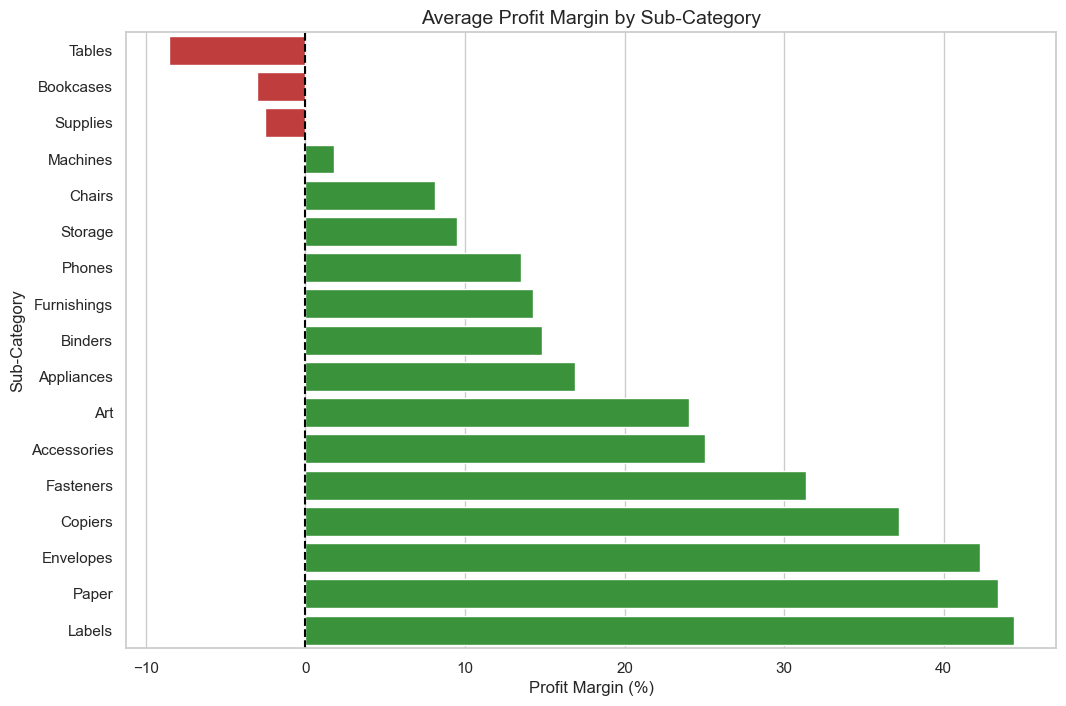

In [19]:
subcat_totals = df.groupby('Sub-Category')[['Sales', 'Profit']].sum()
subcat_totals['Profit Margin (%)'] = (subcat_totals['Profit'] / subcat_totals['Sales']) * 100
subcat_totals = subcat_totals.sort_values(by='Profit Margin (%)')

plt.figure(figsize=(12, 8))
colors = ['#d62728' if m < 0 else '#2ca02c' for m in subcat_totals['Profit Margin (%)']]

sns.barplot(x=subcat_totals['Profit Margin (%)'], y=subcat_totals.index, palette=colors)
plt.title('Average Profit Margin by Sub-Category', fontsize=14)
plt.xlabel('Profit Margin (%)', fontsize=12)
plt.ylabel('Sub-Category', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

### Q9. How does Order Quantity relate to the Discount provided?
*Why it matters:* Are customers getting higher discounts for buying in bulk, or are high discounts being given randomly to small orders?
*Methodology:* Create a box plot combining `Discount` and `Quantity` to visualize the spread of order sizes at each discount level.

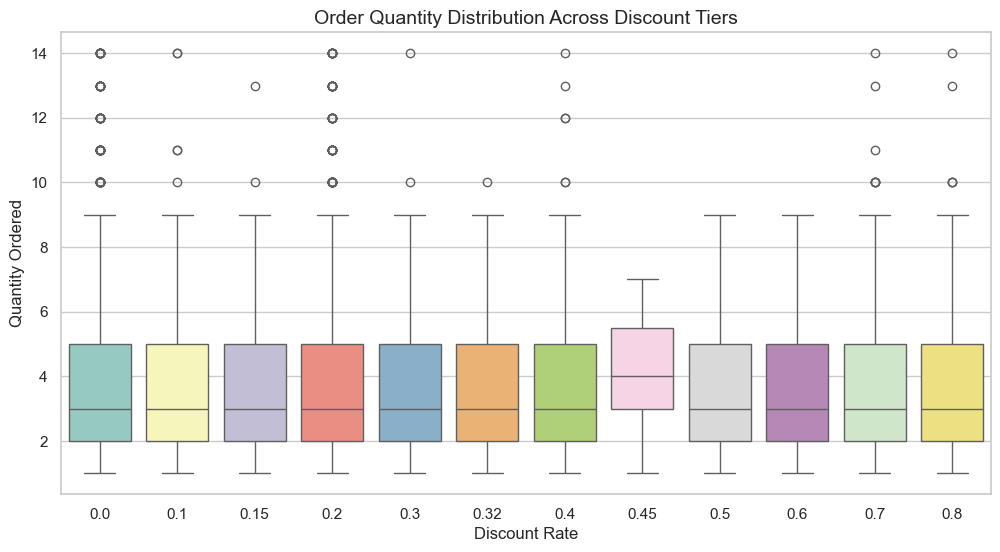

In [20]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Discount', y='Quantity', data=df, palette='Set3')
plt.title('Order Quantity Distribution Across Discount Tiers', fontsize=14)
plt.xlabel('Discount Rate', fontsize=12)
plt.ylabel('Quantity Ordered', fontsize=12)
plt.show()

### Q10. What is the sales performance across different Regions over time?
*Why it matters:* Identifying regional seasonality allows for better localized marketing and resource allocation.
*Methodology:* Group the data by `Year-Month` and `Region`, then plot a multi-line chart using Seaborn.

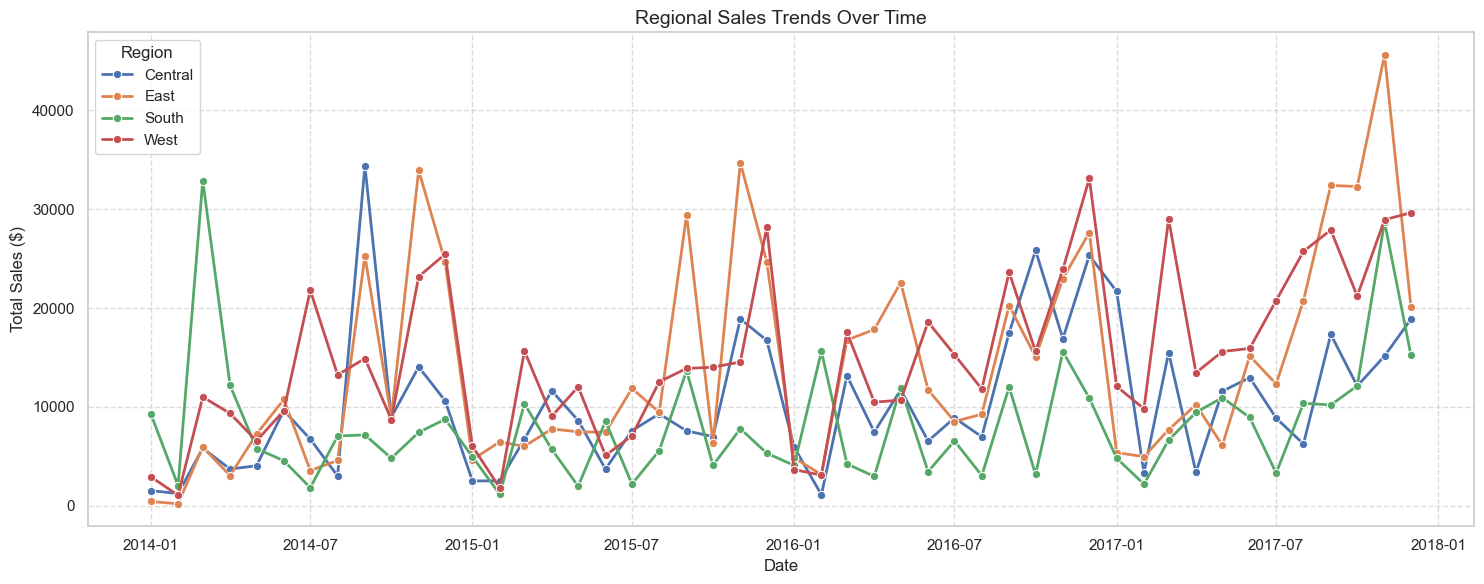

In [21]:
regional_sales = df.groupby(['Year-Month', 'Region'])['Sales'].sum().reset_index()

# Convert Period back to string/datetime for Seaborn
regional_sales['Year-Month'] = regional_sales['Year-Month'].dt.to_timestamp()

plt.figure(figsize=(15, 6))
sns.lineplot(data=regional_sales, x='Year-Month', y='Sales', hue='Region', marker='o', linewidth=2)
plt.title('Regional Sales Trends Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Region')
plt.tight_layout()
plt.show()

---
## Superstore Sales & Profitability Analysis

This project explores patterns in sales, profit, and discounts using the Superstore dataset.  
The goal is to identify which categories, regions, and products drive profits or losses and to evaluate whether discounting influences profitability.

Key questions:
- Are there categories with high sales but low profit?
- Which sub-categories drive losses?
- Do discounts explain negative profitability?
- How do profit patterns vary by region and over time?

## Importing libraries.

In [22]:
import numpy as np
import pandas as pd
# import seaborn as sns
import matplotlib.pyplot as plt

## Load dataset.

In [23]:
df = pd.read_csv("data_Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Data overview

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [25]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [26]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

# Percentage missing

In [27]:
(df.isnull().mean() * 100).round(2)

Row ID           0.0
Order ID         0.0
Order Date       0.0
Ship Date        0.0
Ship Mode        0.0
Customer ID      0.0
Customer Name    0.0
Segment          0.0
Country          0.0
City             0.0
State            0.0
Postal Code      0.0
Region           0.0
Product ID       0.0
Category         0.0
Sub-Category     0.0
Product Name     0.0
Sales            0.0
Quantity         0.0
Discount         0.0
Profit           0.0
dtype: float64

## Data Cleaning.

In [28]:
df.columns = df.columns.str.strip()
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=False, errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=False, errors='coerce')
# Order Date should NOT be after Ship Date

df['Date Issue'] = df['Order Date'] > df['Ship Date']
df['Date Issue'].sum()  #Adds a column "Date Issue"

np.int64(0)

# Check conversion errors

In [29]:
df[['Order Date','Ship Date']].isnull().sum()

Order Date    0
Ship Date     0
dtype: int64

# Look for bad rows.

In [30]:
df[df['Date Issue'] == True]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Date Issue


## Key Performance metrics calculations.

In [31]:
# 1. Total sales
total_sales = df['Sales'].sum()
total_sales

np.float64(2297200.8603000003)

In [32]:
# 2. Total profit
total_profit = df['Profit'].sum()
total_profit

np.float64(286397.0217)

In [33]:
# 3. Total discount
total_discount = df['Discount'].sum()
total_discount

np.float64(1561.09)

In [34]:
# 4. Profit Margin
profit_margin = total_profit / total_sales
profit_margin

np.float64(0.12467217240315603)

## Sales vs Profit by Category

In [35]:
category_summary = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit':'sum'
}).sort_values('Profit')

category_summary

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


## Visualisation. Sales vs Profit by Category

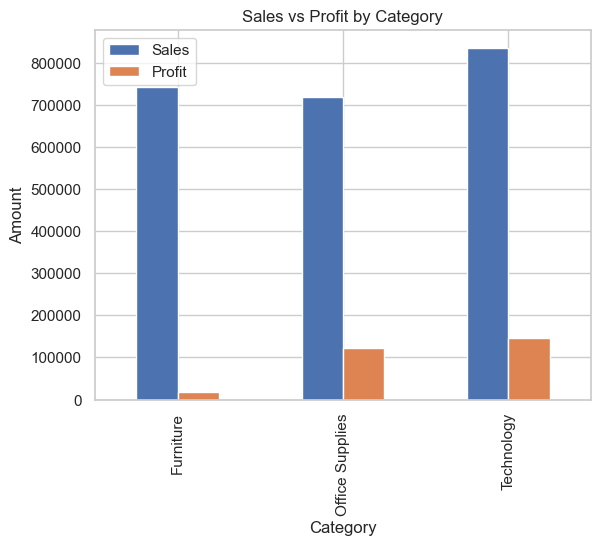

In [36]:
category_summary.plot(kind='bar')
plt.title("Sales vs Profit by Category")
plt.ylabel("Amount")
plt.show()

# Loss making subcategory

In [37]:
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
subcat_profit.head(10)

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Name: Profit, dtype: float64

# Does discounts relate to loss?

In [38]:
df[['Discount','Profit']].corr()

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


# by subcategory

In [39]:
df.groupby('Sub-Category')[['Discount','Profit']].mean().sort_values('Profit')

,Discount,Profit
Sub-Category,,
Tables,0.261285,-55.565771
Bookcases,0.211140,-15.230509
Supplies,0.076842,-6.258418
Fasteners,0.082028,4.375660
Art,0.074874,8.200737
Furnishings,0.138349,13.645918
Labels,0.068681,15.236962
Binders,0.372292,19.843574
Paper,0.074891,24.856620


# Visualisation. Profit by Region

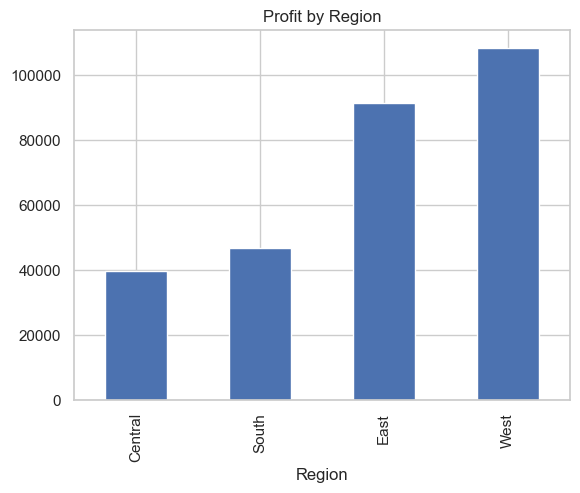

In [40]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values()
region_profit.plot(kind='bar', title='Profit by Region')
plt.show()

# Visualisation. Monthly trend

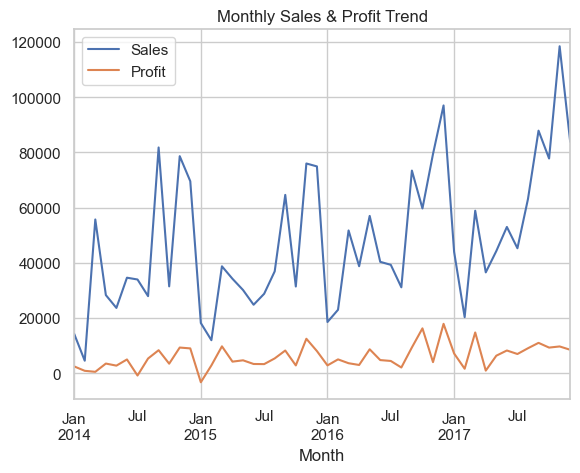

In [41]:
df['Month'] = df['Order Date'].dt.to_period('M')

monthly = df.groupby('Month')[['Sales','Profit']].sum()

monthly.plot(title='Monthly Sales & Profit Trend')
plt.show()

## Top loss orders

In [42]:
df.sort_values('Profit').head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Date Issue,Month
7772,7773,CA-2016-108196,2016-11-25,2016-12-02,Standard Class,CS-12505,Cindy Stewart,Consumer,United States,Lancaster,...,TEC-MA-10000418,Technology,Machines,Cubify CubeX 3D Printer Double Head Print,4499.985,5,0.7,-6599.9780,False,2016-11
683,684,US-2017-168116,2017-11-04,2017-11-04,Same Day,GT-14635,Grant Thornton,Corporate,United States,Burlington,...,TEC-MA-10004125,Technology,Machines,Cubify CubeX 3D Printer Triple Head Print,7999.980,4,0.5,-3839.9904,False,2017-11
9774,9775,CA-2014-169019,2014-07-26,2014-07-30,Standard Class,LF-17185,Luke Foster,Consumer,United States,San Antonio,...,OFF-BI-10004995,Office Supplies,Binders,GBC DocuBind P400 Electric Binding System,2177.584,8,0.8,-3701.8928,False,2014-07
3011,3012,CA-2017-134845,2017-04-17,2017-04-23,Standard Class,SR-20425,Sharelle Roach,Home Office,United States,Louisville,...,TEC-MA-10000822,Technology,Machines,Lexmark MX611dhe Monochrome Laser Printer,2549.985,5,0.7,-3399.9800,False,2017-04
4991,4992,US-2017-122714,2017-12-07,2017-12-13,Standard Class,HG-14965,Henry Goldwyn,Corporate,United States,Chicago,...,OFF-BI-10001120,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,1889.990,5,0.8,-2929.4845,False,2017-12
3151,3152,CA-2015-147830,2015-12-15,2015-12-18,First Class,NF-18385,Natalie Fritzler,Consumer,United States,Newark,...,TEC-MA-10000418,Technology,Machines,Cubify CubeX 3D Printer Double Head Print,1799.994,2,0.7,-2639.9912,False,2015-12
5310,5311,CA-2017-131254,2017-11-19,2017-11-21,First Class,NC-18415,Nathan Cano,Consumer,United States,Houston,...,OFF-BI-10003527,Office Supplies,Binders,Fellowes PB500 Electric Punch Plastic Comb Bin...,1525.188,6,0.8,-2287.7820,False,2017-11
9639,9640,CA-2015-116638,2015-01-28,2015-01-31,Second Class,JH-15985,Joseph Holt,Consumer,United States,Concord,...,FUR-TA-10000198,Furniture,Tables,Chromcraft Bull-Nose Wood Oval Conference Tabl...,4297.644,13,0.4,-1862.3124,False,2015-01
1199,1200,CA-2016-130946,2016-04-08,2016-04-12,Standard Class,ZC-21910,Zuschuss Carroll,Consumer,United States,Houston,...,OFF-BI-10004995,Office Supplies,Binders,GBC DocuBind P400 Electric Binding System,1088.792,4,0.8,-1850.9464,False,2016-04
2697,2698,CA-2014-145317,2014-03-18,2014-03-23,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,...,TEC-MA-10002412,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,22638.480,6,0.5,-1811.0784,False,2014-03


### Key Finding
- Furniture shows strong sales but low profitability, driven by heavy losses in Tables.
- Discount levels do not consistently explain the losses, suggesting other cost drivers.

## Other visuals. Correlation heatmaps.

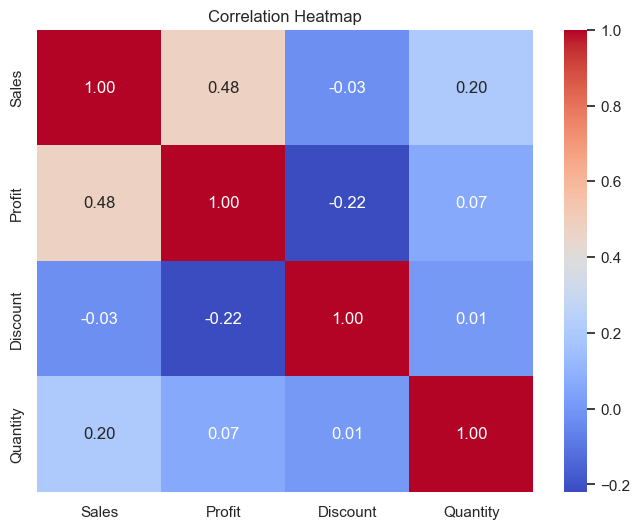

In [43]:
import seaborn as sns

numeric_cols = df[['Sales', 'Profit', 'Discount', 'Quantity']]  #Selection of the numerical columns.
corr = numeric_cols.corr() #Correlation matrix.

#Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Profit by Category & Region Heatmap

In [44]:
#Pivot table
pivot = df.pivot_table(
    values='Profit',
    index='Category',
    columns='Region',
    aggfunc='sum'
)
pivot

Region,Central,East,South,West
Category,,,,
Furniture,-2871.0494,3046.1658,6771.2061,11504.9503
Office Supplies,8879.9799,41014.5791,19986.3928,52609.8490
Technology,33697.4320,47462.0351,19991.8314,44303.6496


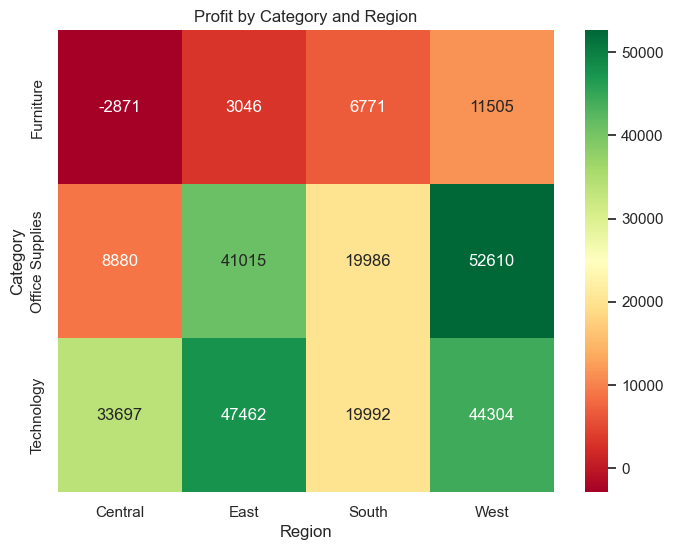

In [45]:
plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, cmap='RdYlGn', fmt=".0f")
plt.title("Profit by Category and Region")
plt.show()

## Subcategory Loss Heatmap

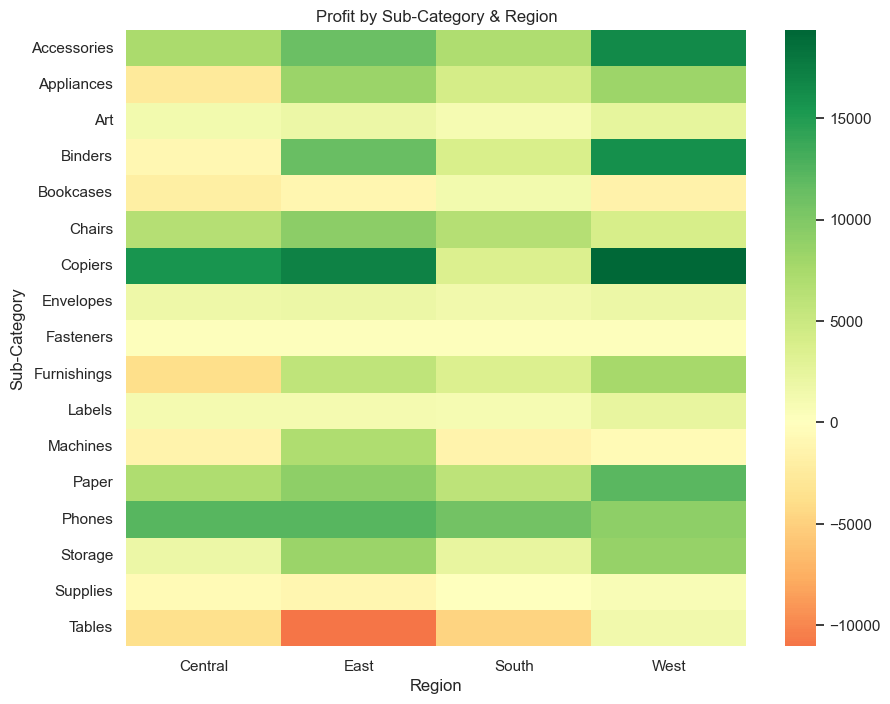

In [46]:
subcat_pivot = df.pivot_table(
    values='Profit',
    index='Sub-Category',
    columns='Region',
    aggfunc='sum'
)

plt.figure(figsize=(10,8))
sns.heatmap(subcat_pivot, cmap='RdYlGn', center=0)
plt.title("Profit by Sub-Category & Region")
plt.show()